In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import auc
import seaborn as sns


In [3]:
#pip install torch torchvision torchaudio
#pip install torch-geometric

In [1]:
%run ../scripts/preprocessing.py


INFO:pyensembl.sequence_data:Loaded sequence dictionary from C:\Users\siddu\AppData\Local\pyensembl\GRCh38\ensembl104\pyensembl\GRCh38\ensembl104\Cache\Homo_sapiens.GRCh38.cdna.all.fa.gz.pickle
INFO:pyensembl.sequence_data:Loaded sequence dictionary from C:\Users\siddu\AppData\Local\pyensembl\GRCh38\ensembl104\pyensembl\GRCh38\ensembl104\Cache\Homo_sapiens.GRCh38.ncrna.fa.gz.pickle
INFO:pyensembl.sequence_data:Loaded sequence dictionary from C:\Users\siddu\AppData\Local\pyensembl\GRCh38\ensembl104\pyensembl\GRCh38\ensembl104\Cache\Homo_sapiens.GRCh38.pep.all.fa.gz.pickle


Number of unmatched proteins: 280
Feature matrix created for 19088 proteins.
Explained variance ratio: [0.81998696 0.04013562 0.02737835 0.02037355 0.01771292 0.01366703
 0.0121516  0.00784211 0.00567791 0.00528535]
Cumulative explained variance: [0.81998696 0.86012258 0.88750094 0.90787449 0.92558741 0.93925444
 0.95140604 0.95924815 0.96492606 0.97021142]
Percentage of proteins after preprocessing with proper RNA feature: 0.9727856487615941
Number of rows dropped: 282
Number of unmatched proteins: 0
Feature matrix created for 10432 proteins.
Explained variance ratio: [0.5345235  0.05026245 0.03675231 0.03263938 0.02301091 0.02149894
 0.01801804 0.01666486 0.01588064 0.01389778]
Cumulative explained variance: [0.5345235  0.58478595 0.62153827 0.65417765 0.67718856 0.69868749
 0.71670554 0.7333704  0.74925104 0.76314882]
Common prefix in 'protein1': 9606.ENSP00000
Common prefix in 'protein2': 9606.ENSP00000
Common prefix in 'rna seq proteins': ENSP00000
Common prefix in 'protein expres

C:\Users\siddu\capstone\PPI-OMEGA\scripts\preprocessing.py:151: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_ppi_data['protein1'] = filtered_ppi_data['protein1'].str.replace(protein1_prefix, '', regex=False)
C:\Users\siddu\capstone\PPI-OMEGA\scripts\preprocessing.py:152: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_ppi_data['protein2'] = filtered_ppi_data['protein2'].str.replace(protein1_prefix, '', regex=False)
C:\Users\siddu\capstone\PPI-OMEGA\scripts\preprocessing.py:164: SettingWithC

Number of proteins with valid features: 9466


In [3]:
%run run_models.py --version 0

c:\Users\siddu\anaconda3\envs\PPIOMEGA_env\Lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not find module 'C:\Users\siddu\anaconda3\envs\PPIOMEGA_env\Lib\site-packages\torch_scatter\_scatter_cuda.pyd' (or one of its dependencies). Try using the full path with constructor syntax.
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
c:\Users\siddu\anaconda3\envs\PPIOMEGA_env\Lib\site-packages\torch_geometric\typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not find module 'C:\Users\siddu\anaconda3\envs\PPIOMEGA_env\Lib\site-packages\torch_sparse\_convert_cuda.pyd' (or one of its dependencies). Try using the full path with constructor syntax.
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


Running Version 0: No Node Features (Only PPI Data)


c:\Users\siddu\anaconda3\envs\PPIOMEGA_env\Lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'train_test_split_edges' is deprecated, use 'transforms.RandomLinkSplit' instead
  warnings.warn(out)


Early stopping triggered at epoch 79. Best AUC: 0.8124
Best model restored with AUC: 0.8124
Saved latent parameters for version 0 to latent_parameters_v0.csv
All metrics saved to metrics_version_0.npz


In [4]:
%run run_models.py --version 1

Running Version 1: Combined Features (RNA + Protein Expression)


c:\Users\siddu\anaconda3\envs\PPIOMEGA_env\Lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'train_test_split_edges' is deprecated, use 'transforms.RandomLinkSplit' instead
  warnings.warn(out)


Epoch 100/200 - Loss: 0.9836, AUC: 0.9089, AP: 0.9182
Early stopping triggered at epoch 185. Best AUC: 0.9172
Best model restored with AUC: 0.9172
Saved latent parameters for version 1 to latent_parameters_v1.csv
All metrics saved to metrics_version_1.npz


In [5]:
%run run_models.py --version 2

Running Version 2: RNA Features Only


c:\Users\siddu\anaconda3\envs\PPIOMEGA_env\Lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'train_test_split_edges' is deprecated, use 'transforms.RandomLinkSplit' instead
  warnings.warn(out)


Epoch 100/200 - Loss: 1.0384, AUC: 0.8724, AP: 0.8906
Early stopping triggered at epoch 181. Best AUC: 0.8861
Best model restored with AUC: 0.8861
Saved latent parameters for version 2 to latent_parameters_v2.csv
All metrics saved to metrics_version_2.npz


In [6]:
%run run_models.py --version 3

Running Version 3: Protein Expression Features Only


c:\Users\siddu\anaconda3\envs\PPIOMEGA_env\Lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'train_test_split_edges' is deprecated, use 'transforms.RandomLinkSplit' instead
  warnings.warn(out)


Epoch 100/200 - Loss: 0.9952, AUC: 0.9025, AP: 0.9108
Early stopping triggered at epoch 155. Best AUC: 0.9073
Best model restored with AUC: 0.9073
Saved latent parameters for version 3 to latent_parameters_v3.csv
All metrics saved to metrics_version_3.npz


In [2]:
metrics_dict_ppi = np.load('metrics_version_0.npz', allow_pickle = True)
metrics_dict_combined = np.load('metrics_version_1.npz', allow_pickle = True)
metrics_dict_rna = np.load('metrics_version_2.npz', allow_pickle = True)
metrics_dict_pe = np.load('metrics_version_3.npz', allow_pickle = True)

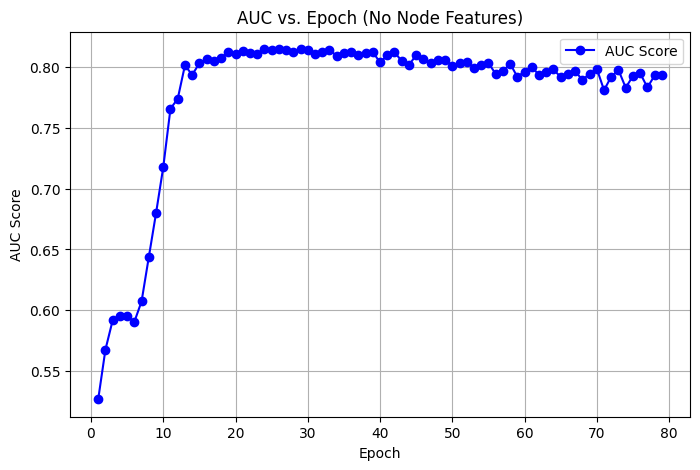

In [6]:
# Plot AUC over epochs
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(metrics_dict_ppi["auc_values"]) + 1), metrics_dict_ppi["auc_values"], marker='o', linestyle='-', color='b', label="AUC Score")
plt.xlabel("Epoch")
plt.ylabel("AUC Score")
plt.title("AUC vs. Epoch (No Node Features)")
plt.legend()
plt.grid(True)
plt.show()

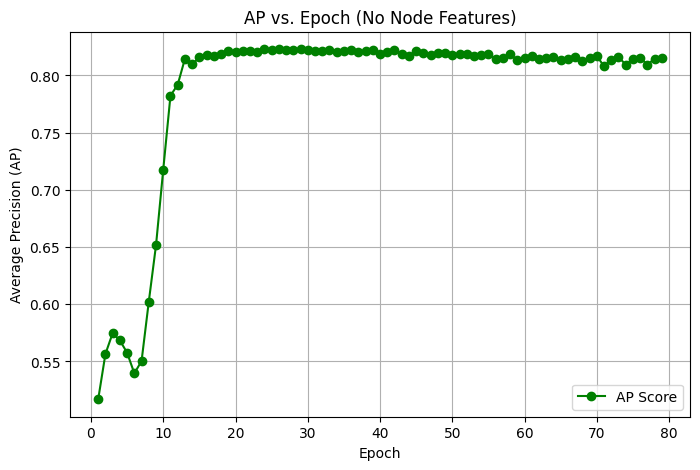

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(metrics_dict_ppi["ap_values"]) + 1), metrics_dict_ppi["ap_values"], marker='o', linestyle='-', color='g', label="AP Score")
plt.xlabel("Epoch")
plt.ylabel("Average Precision (AP)")
plt.title("AP vs. Epoch (No Node Features)")
plt.legend()
plt.grid(True)
plt.show()

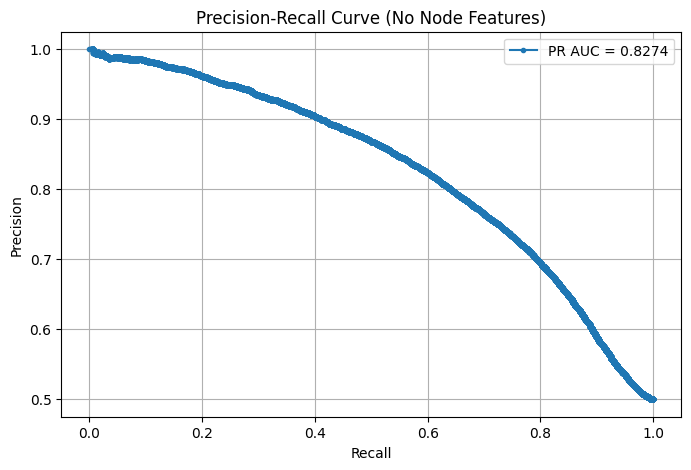

In [9]:
precision = metrics_dict_ppi["precision_values"][-1]  # Last epoch's precision
recall = metrics_dict_ppi["recall_values"][-1]  # Last epoch's recall
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, marker='.', label=f'PR AUC = {pr_auc:.4f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (No Node Features)")
plt.legend()
plt.grid(True)
plt.show()

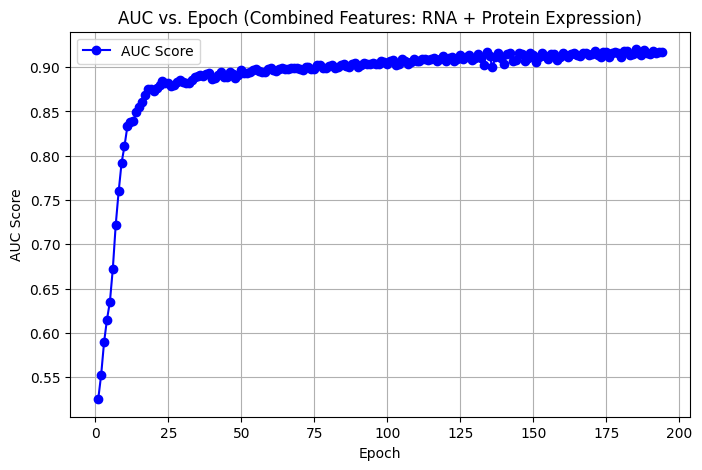

In [10]:
# Plot AUC over epochs
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(metrics_dict_combined["auc_values"]) + 1), metrics_dict_combined["auc_values"], marker='o', linestyle='-', color='b', label="AUC Score")
plt.xlabel("Epoch")
plt.ylabel("AUC Score")
plt.title("AUC vs. Epoch (Combined Features: RNA + Protein Expression)")
plt.legend()
plt.grid(True)
plt.show()

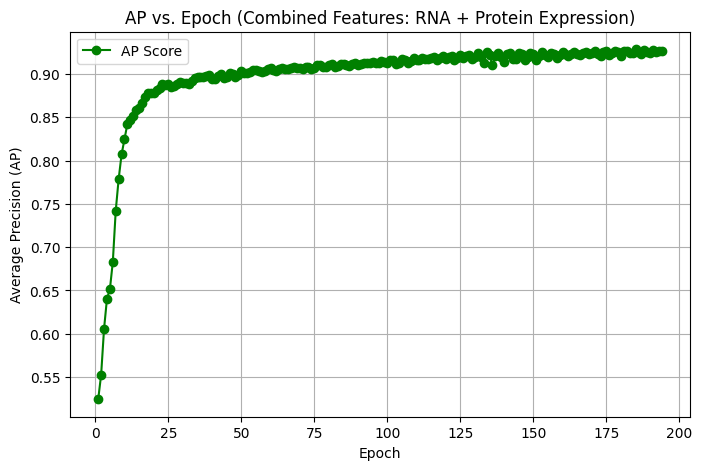

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(metrics_dict_combined["ap_values"]) + 1), metrics_dict_combined["ap_values"], marker='o', linestyle='-', color='g', label="AP Score")
plt.xlabel("Epoch")
plt.ylabel("Average Precision (AP)")
plt.title("AP vs. Epoch (Combined Features: RNA + Protein Expression)")
plt.legend()
plt.grid(True)
plt.show()

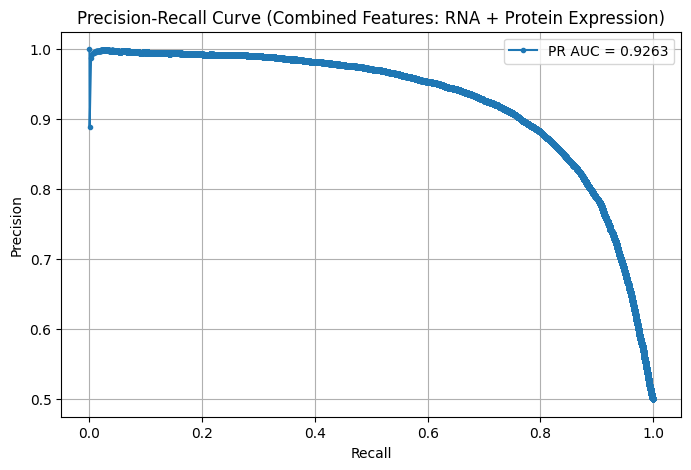

In [12]:
precision = metrics_dict_combined["precision_values"][-1]  # Last epoch's precision
recall = metrics_dict_combined["recall_values"][-1]  # Last epoch's recall
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, marker='.', label=f'PR AUC = {pr_auc:.4f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Combined Features: RNA + Protein Expression)")
plt.legend()
plt.grid(True)
plt.show()

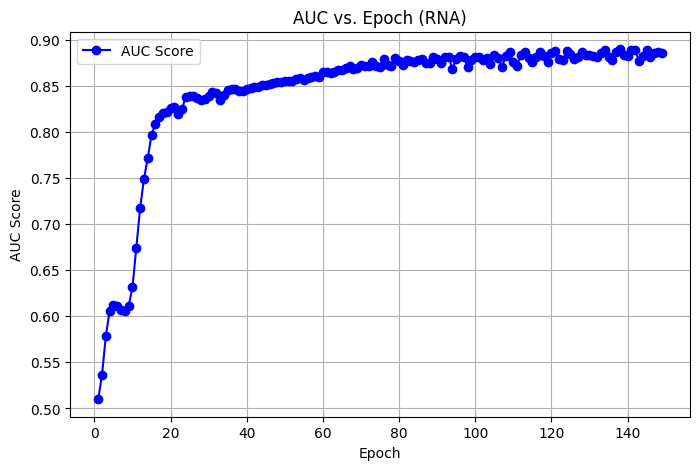

In [13]:
# Plot AUC over epochs
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(metrics_dict_rna["auc_values"]) + 1), metrics_dict_rna["auc_values"], marker='o', linestyle='-', color='b', label="AUC Score")
plt.xlabel("Epoch")
plt.ylabel("AUC Score")
plt.title("AUC vs. Epoch (RNA)")
plt.legend()
plt.grid(True)
plt.show()

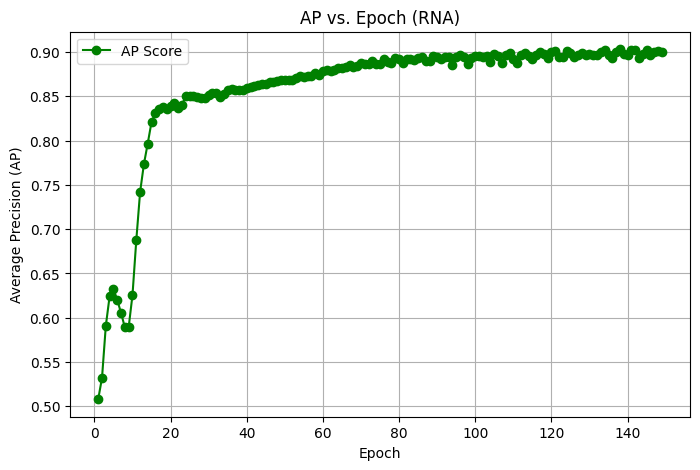

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(metrics_dict_rna["ap_values"]) + 1), metrics_dict_rna["ap_values"], marker='o', linestyle='-', color='g', label="AP Score")
plt.xlabel("Epoch")
plt.ylabel("Average Precision (AP)")
plt.title("AP vs. Epoch (RNA)")
plt.legend()
plt.grid(True)
plt.show()

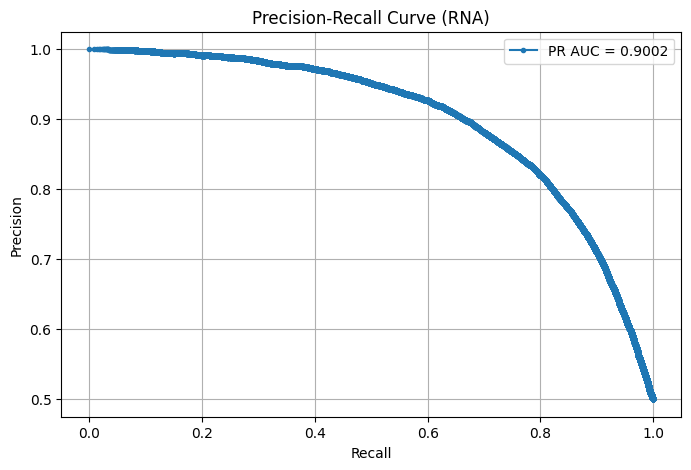

In [15]:
precision = metrics_dict_rna["precision_values"][-1]  # Last epoch's precision
recall = metrics_dict_rna["recall_values"][-1]  # Last epoch's recall
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, marker='.', label=f'PR AUC = {pr_auc:.4f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (RNA)")
plt.legend()
plt.grid(True)
plt.show()

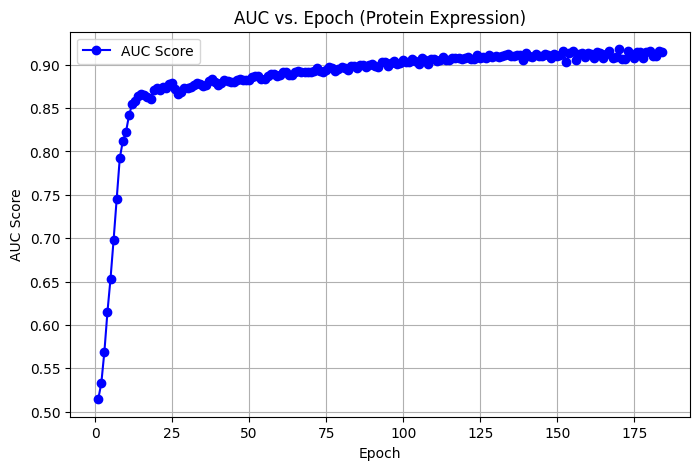

In [16]:
# Plot AUC over epochs
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(metrics_dict_pe["auc_values"]) + 1), metrics_dict_pe["auc_values"], marker='o', linestyle='-', color='b', label="AUC Score")
plt.xlabel("Epoch")
plt.ylabel("AUC Score")
plt.title("AUC vs. Epoch (Protein Expression)")
plt.legend()
plt.grid(True)
plt.show()

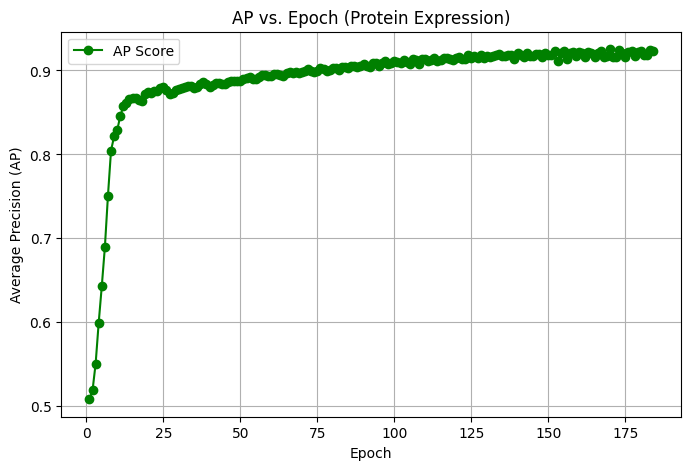

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(metrics_dict_pe["ap_values"]) + 1), metrics_dict_pe["ap_values"], marker='o', linestyle='-', color='g', label="AP Score")
plt.xlabel("Epoch")
plt.ylabel("Average Precision (AP)")
plt.title("AP vs. Epoch (Protein Expression)")
plt.legend()
plt.grid(True)
plt.show()

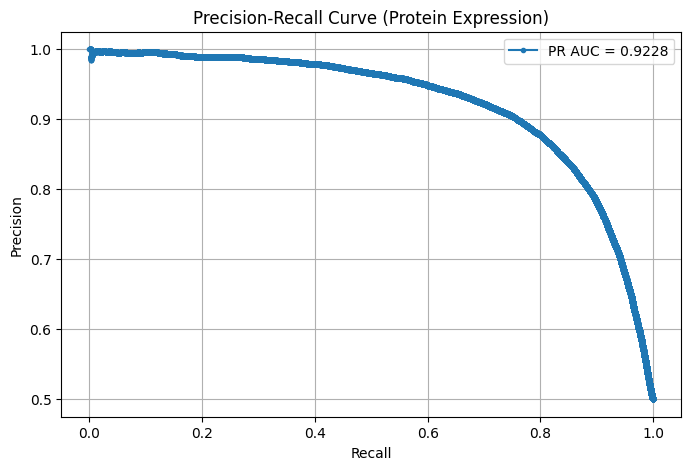

In [18]:
precision = metrics_dict_pe["precision_values"][-1]  # Last epoch's precision
recall = metrics_dict_pe["recall_values"][-1]  # Last epoch's recall
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, marker='.', label=f'PR AUC = {pr_auc:.4f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Protein Expression)")
plt.legend()
plt.grid(True)
plt.show()

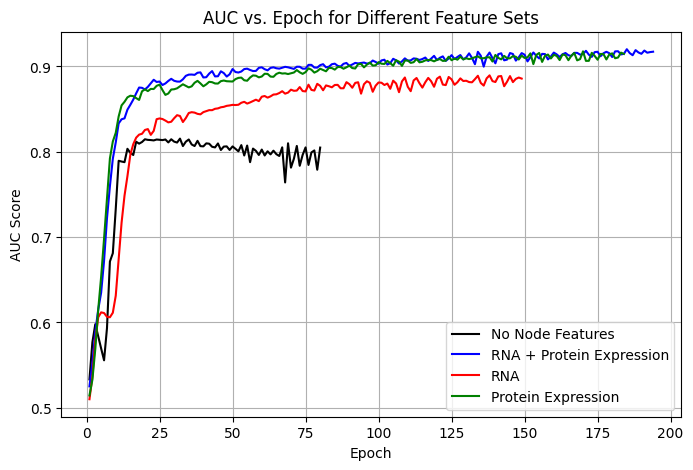

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, len(metrics_dict_ppi["auc_values"]) + 1), 
         metrics_dict_ppi["auc_values"], linestyle='-', color='black', label="No Node Features")

# Plot AUC for combined features
plt.plot(range(1, len(metrics_dict_combined["auc_values"]) + 1), 
         metrics_dict_combined["auc_values"], linestyle='-', color='b', label="RNA + Protein Expression")

# Plot AUC for RNA
plt.plot(range(1, len(metrics_dict_rna["auc_values"]) + 1), 
         metrics_dict_rna["auc_values"], linestyle='-', color='r', label="RNA")

# Plot AUC for Protein Expression
plt.plot(range(1, len(metrics_dict_pe["auc_values"]) + 1), 
         metrics_dict_pe["auc_values"],  linestyle='-', color='g', label="Protein Expression")

# Labels and Title
plt.xlabel("Epoch")
plt.ylabel("AUC Score")
plt.title("AUC vs. Epoch for Different Feature Sets")
plt.legend()
plt.grid(True)

plt.show()

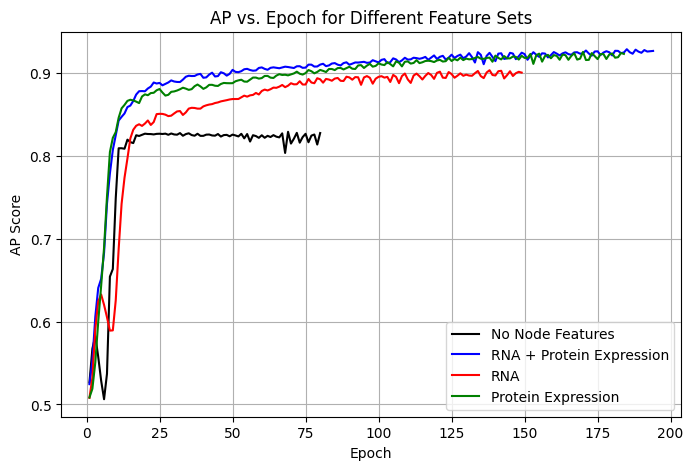

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, len(metrics_dict_ppi["ap_values"]) + 1), 
         metrics_dict_ppi["ap_values"], linestyle='-', color='black', label="No Node Features")

# Plot AUC for combined features
plt.plot(range(1, len(metrics_dict_combined["ap_values"]) + 1), 
         metrics_dict_combined["ap_values"], linestyle='-', color='b', label="RNA + Protein Expression")

# Plot AUC for RNA
plt.plot(range(1, len(metrics_dict_rna["ap_values"]) + 1), 
         metrics_dict_rna["ap_values"], linestyle='-', color='r', label="RNA")

# Plot AUC for Protein Expression
plt.plot(range(1, len(metrics_dict_pe["ap_values"]) + 1), 
         metrics_dict_pe["ap_values"],  linestyle='-', color='g', label="Protein Expression")

# Labels and Title
plt.xlabel("Epoch")
plt.ylabel("AP Score")
plt.title("AP vs. Epoch for Different Feature Sets")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
%run baseline_model.py


c:\Users\siddu\anaconda3\envs\pytorch_audio\Lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'train_test_split_edges' is deprecated, use 'transforms.RandomLinkSplit' instead
  warnings.warn(out)


Baseline Model: Predicting the Most Occurring Class
Test positive edge count: 27126
Test negative edge count: 27126
Predicted majority class: 0.0
AUC: 0.5000
Average Precision (AP): 0.5000


In [ ]:

# %run vgae_cv.py

Total hyperparameter combinations: 27


Hyperparameter Search:   0%|          | 0/27 [00:00<?, ?config/s, params={'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0005}]c:\Users\siddu\anaconda3\envs\pytorch_audio\Lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'train_test_split_edges' is deprecated, use 'transforms.RandomLinkSplit' instead
  warnings.warn(out)


Epoch 100/200 - Loss: 1.1012, AUC: 0.8412, AP: 0.8533


Hyperparameter Search:   0%|          | 0/27 [01:20<?, ?config/s, params={'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0005}]


KeyboardInterrupt: 

In [10]:
latent_variables = pd.read_csv('latent_parameters_v1.csv')
latent_variables['mu'] = latent_variables['mu'].apply(ast.literal_eval)
latent_variables['logstd'] = latent_variables['logstd'].apply(ast.literal_eval)



In [11]:
# Function to round elements in a list
def round_list(lst, decimals=3):
    return [round(x, decimals) for x in lst]

# Apply rounding to 'mu' and 'logstd' columns
latent_variables["mu"] = latent_variables["mu"].apply(lambda x: round_list(x, 3))
latent_variables["logstd"] = latent_variables["logstd"].apply(lambda x: round_list(x, 3))

In [14]:
latent_variables

,version,epoch,node,mu,logstd
0,1,1,0,"[0.009, -0.067, 0.022, -0.042, 0.043, -0.03, -...","[0.014, -0.036, 0.0, -0.053, -0.051, 0.034, -0..."
1,1,1,1,"[0.027, -0.162, 0.035, -0.121, -0.011, -0.078,...","[0.153, -0.188, 0.038, -0.134, -0.148, 0.041, ..."
2,1,1,2,"[0.154, -0.184, 0.069, -0.004, -0.011, -0.092,...","[0.104, -0.079, 0.025, -0.063, -0.173, -0.018,..."
3,1,1,3,"[0.057, -0.132, -0.051, -0.019, -0.048, -0.073...","[0.122, -0.127, -0.003, -0.023, -0.045, -0.025..."
4,1,1,4,"[0.019, -0.055, 0.125, -0.019, -0.004, 0.035, ...","[0.121, -0.154, 0.168, -0.167, -0.147, -0.058,..."
...,...,...,...,...,...
1457759,1,154,9461,"[0.084, 0.075, -0.156, -0.107, 0.185, 0.125, 0...","[-4.688, -5.146, -5.678, -5.26, -5.361, -5.593..."
1457760,1,154,9462,"[-0.075, 0.076, 0.076, -0.173, 0.036, 0.072, -...","[-1.572, -1.895, -1.902, -1.693, -1.717, -1.88..."
1457761,1,154,9463,"[0.238, -0.504, -0.497, -0.042, -0.035, 0.009,...","[-2.998, -3.404, -3.733, -3.277, -3.208, -3.45..."
1457762,1,154,9464,"[0.057, -0.434, 0.042, -0.048, -0.487, 0.087, ...","[-2.539, -2.967, -3.104, -2.799, -2.933, -2.82..."


In [15]:
latent_variables_sampled = latent_variables[latent_variables['epoch'] % 10 == 0]

In [16]:
latent_variables_sampled.to_csv('latent_variables_sampled.csv')

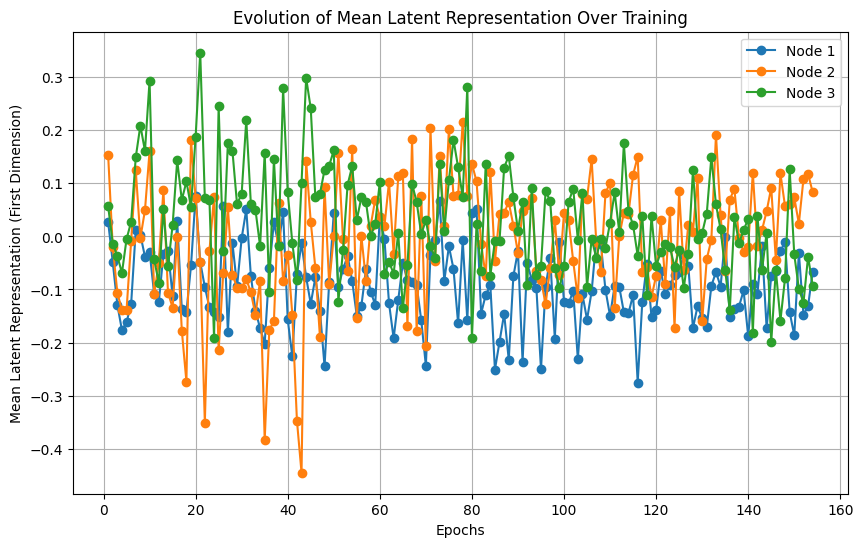

In [5]:
selected_nodes = [1, 2, 3]
df_subset = latent_variables[latent_variables['node'].isin(selected_nodes)]

# Plot each node's mean vector (choosing the first dimension of mu for simplicity)
plt.figure(figsize=(10, 6))
for node in selected_nodes:
    node_df = df_subset[df_subset['node'] == node]
    mu_first_dim = np.array(node_df['mu'].tolist())[:, 0]  # Extract first dim of mu
    plt.plot(node_df['epoch'], mu_first_dim, marker='o', label=f'Node {node}')

plt.xlabel("Epochs")
plt.ylabel("Mean Latent Representation (First Dimension)")
plt.title("Evolution of Mean Latent Representation Over Training")
plt.legend()
plt.grid()
plt.show()

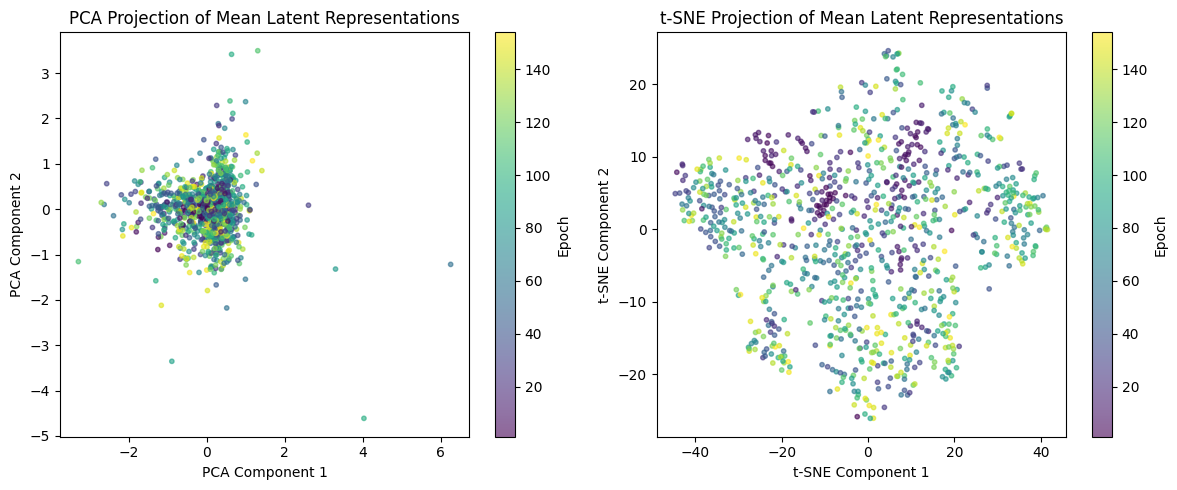

In [6]:
example_df = latent_variables.sample(1000, random_state=42)  # Sample randomly across epochs
mu_matrix = np.array(example_df['mu'].tolist())  # Shape: (num_nodes * epochs, latent_dim)

# Reduce dimensionality using PCA (to 2D)
pca = PCA(n_components=2)
mu_pca = pca.fit_transform(mu_matrix)

# Reduce dimensionality using t-SNE (to 2D)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
mu_tsne = tsne.fit_transform(mu_matrix)

# Plot PCA
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(mu_pca[:, 0], mu_pca[:, 1], alpha=0.6, s=10, c=example_df['epoch'], cmap='viridis')
plt.colorbar(label='Epoch')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Projection of Mean Latent Representations")

# Plot t-SNE
plt.subplot(1, 2, 2)
plt.scatter(mu_tsne[:, 0], mu_tsne[:, 1], alpha=0.6, s=10, c=example_df['epoch'], cmap='viridis')
plt.colorbar(label='Epoch')
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Projection of Mean Latent Representations")

plt.tight_layout()
plt.show()

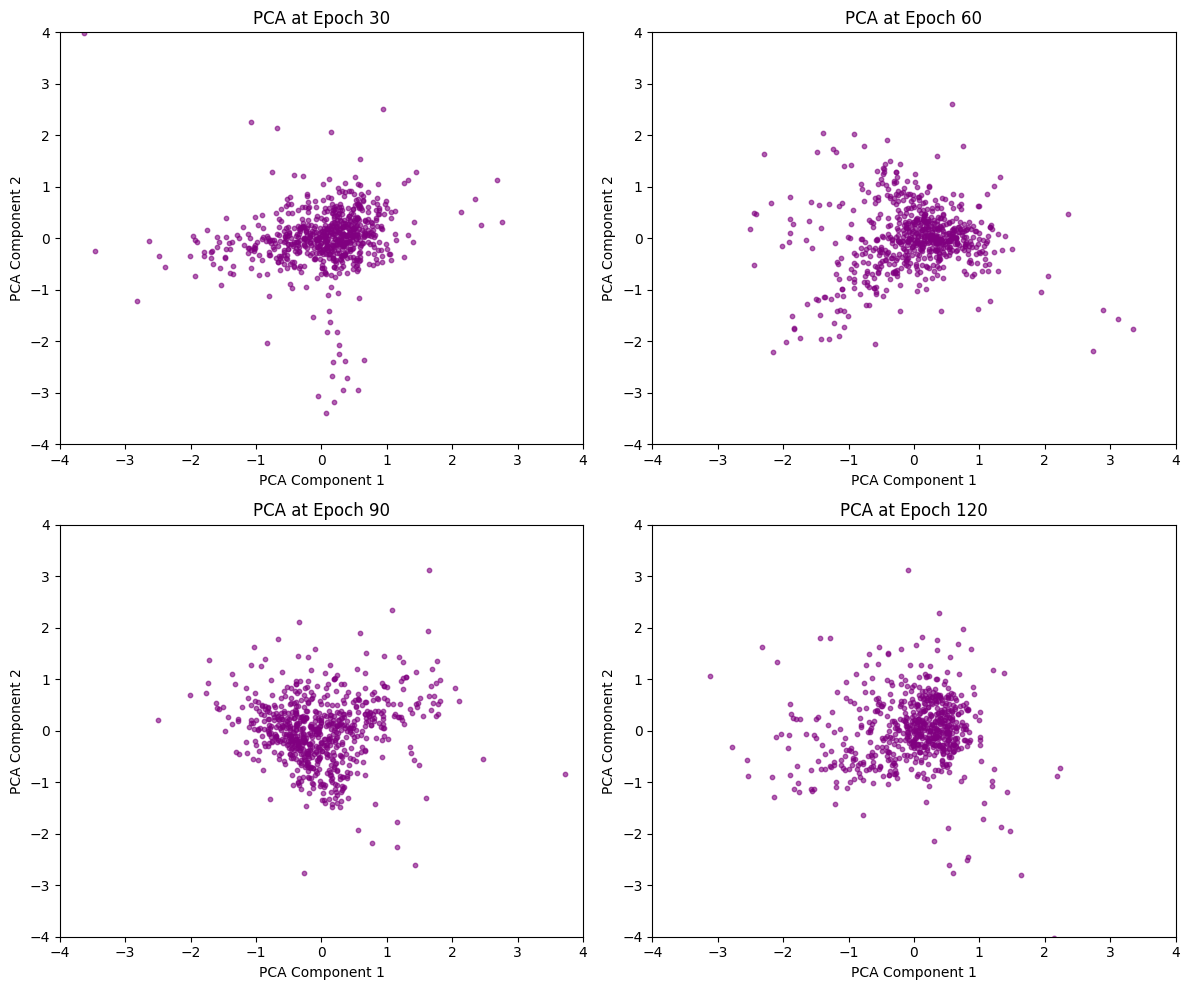

In [ ]:
example_df = latent_variables.sample(10000, random_state=42)

epochs_to_plot = [30, 60, 90, 120]

pca_results = {}

for epoch in epochs_to_plot:
    subset = example_df[example_df['epoch'] == epoch]
    mu_subset = np.array(subset['mu'].tolist())

    pca = PCA(n_components=2)
    pca_results[epoch] = pca.fit_transform(mu_subset)

all_x = np.concatenate([pca_results[epoch][:, 0] for epoch in epochs_to_plot])
all_y = np.concatenate([pca_results[epoch][:, 1] for epoch in epochs_to_plot])
x_min, x_max = all_x.min(), all_x.max()
y_min, y_max = all_y.min(), all_y.max()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # Flatten for easy indexing

for i, epoch in enumerate(epochs_to_plot):
    axes[i].scatter(pca_results[epoch][:, 0], pca_results[epoch][:, 1], alpha=0.6, s=10, color='purple')  # No colors
    axes[i].set_title(f"PCA at Epoch {epoch}")
    axes[i].set_xlabel("PCA Component 1")
    axes[i].set_ylabel("PCA Component 2")
    axes[i].set_xlim(-4, 4)  # Fixed x-axis
    axes[i].set_ylim(-4, 4)  # Fixed y-axis

plt.tight_layout()
plt.show()

plt.show()


In [4]:
latent_variables = pd.read_csv('latent_variables_sampled.csv')
latent_variables['mu'] = latent_variables['mu'].apply(ast.literal_eval)
latent_variables['logstd'] = latent_variables['logstd'].apply(ast.literal_eval)

In [5]:
latent_variables

,Unnamed: 0,version,epoch,node,mu,logstd
0,85194,1,10,0,"[-0.128, 0.084, -0.031, -0.073, 0.069, 0.045, ...","[-0.765, -0.835, -0.777, -1.075, -1.12, -0.985..."
1,85195,1,10,1,"[-0.028, -0.09, -0.04, -0.161, -0.002, -0.065,...","[-1.657, -1.999, -1.605, -2.225, -2.58, -2.142..."
2,85196,1,10,2,"[0.161, -0.045, -0.041, 0.018, -0.152, -0.257,...","[-1.934, -2.124, -1.585, -2.609, -2.94, -2.237..."
3,85197,1,10,3,"[0.294, -0.088, -0.007, -0.155, -0.077, -0.061...","[-1.214, -1.327, -1.062, -1.551, -1.789, -1.37..."
4,85198,1,10,4,"[-0.158, 0.172, -0.049, 0.008, 0.085, 0.057, 0...","[-1.229, -1.819, -1.348, -2.063, -2.182, -1.88..."
...,...,...,...,...,...,...
141985,1419895,1,150,9461,"[0.009, -0.078, -0.098, 0.026, 0.188, 0.251, 0...","[-4.919, -5.601, -5.884, -5.542, -5.473, -5.86..."
141986,1419896,1,150,9462,"[0.037, 0.148, -0.061, -0.258, 0.149, 0.255, -...","[-1.755, -2.165, -2.206, -1.998, -1.9, -2.111,..."
141987,1419897,1,150,9463,"[0.276, -0.435, -0.572, -0.079, -0.067, 0.091,...","[-3.028, -3.612, -3.869, -3.575, -3.342, -3.64..."
141988,1419898,1,150,9464,"[0.11, -0.286, 0.126, 0.015, -0.588, -0.14, 0....","[-2.551, -2.88, -3.19, -2.853, -3.036, -2.912,..."


C:\Users\siddu\AppData\Local\Temp\ipykernel_22032\3960345417.py:37: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axes[i].scatter(tsne_results[epoch][:, 0], tsne_results[epoch][:, 1], alpha=0.6, s=10, cmap='viridis')


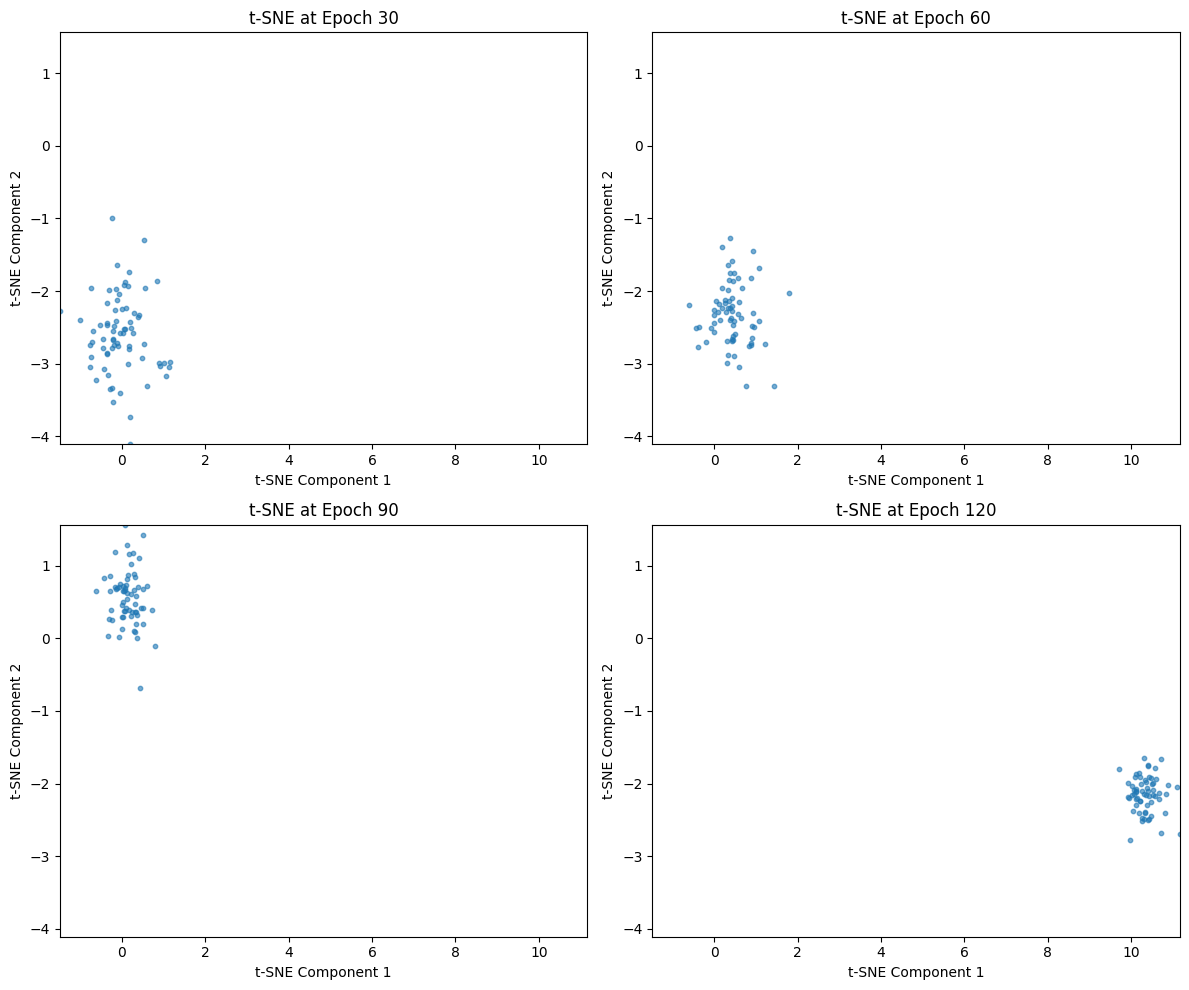

In [ ]:
# Sample randomly across epochs
example_df = latent_variables.sample(1000, random_state=42)

# Extract the latent representations
mu_matrix = np.array(example_df['mu'].tolist())  # Shape: (num_nodes * epochs, latent_dim)

# Select specific epochs for visualization
epochs_to_plot = [30, 60, 90, 120]

# Initialize a dictionary to store t-SNE results
tsne_results = {}

# Compute t-SNE for all selected epochs first
for epoch in epochs_to_plot:
    subset = example_df[example_df['epoch'] == epoch]
    mu_subset = np.array(subset['mu'].tolist())

    tsne = TSNE(n_components=2, perplexity=60, random_state=42)
    tsne_results[epoch] = tsne.fit_transform(mu_subset)

# Determine global axis limits
all_x = np.concatenate([tsne_results[epoch][:, 0] for epoch in epochs_to_plot])
all_y = np.concatenate([tsne_results[epoch][:, 1] for epoch in epochs_to_plot])
x_min, x_max = all_x.min(), all_x.max()
y_min, y_max = all_y.min(), all_y.max()

# Set up 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # Flatten for easy indexing

# Plot t-SNE for each epoch with fixed axis limits
for i, epoch in enumerate(epochs_to_plot):
    axes[i].scatter(tsne_results[epoch][:, 0], tsne_results[epoch][:, 1], alpha=0.6, s=10, cmap='viridis')
    axes[i].set_title(f"t-SNE at Epoch {epoch}")
    axes[i].set_xlabel("t-SNE Component 1")
    axes[i].set_ylabel("t-SNE Component 2")
    axes[i].set_xlim(x_min, x_max)  # Fixed x-axis
    axes[i].set_ylim(y_min, y_max)  # Fixed y-axis

plt.tight_layout()
plt.show()


In [23]:
example_df

,Unnamed: 0,version,epoch,node,mu,logstd
45574,471544,1,50,7710,"[0.09, -0.345, 0.098, -0.059, -0.392, -0.318, ...","[-4.955, -6.082, -5.049, -6.462, -5.897, -5.78..."
133148,1411058,1,150,624,"[-0.244, -0.004, 0.292, 0.231, 0.116, 0.115, 0...","[-3.075, -3.463, -3.603, -3.477, -3.6, -3.76, ..."
32902,373678,1,40,4504,"[-0.19, 0.643, 0.002, -0.264, 0.395, 0.307, 0....","[-3.087, -2.961, -3.175, -3.935, -3.594, -3.82..."
10576,180964,1,20,1110,"[-0.301, 0.123, 0.09, 0.223, -0.362, -0.09, -0...","[-4.368, -4.785, -4.197, -5.68, -5.823, -5.052..."
132276,1324992,1,140,9218,"[0.096, 0.099, 0.164, -0.086, -0.186, -0.106, ...","[-2.288, -2.504, -2.601, -2.489, -2.475, -2.56..."
...,...,...,...,...,...,...
118796,1226318,1,130,5204,"[-0.148, -0.488, -0.116, -0.269, -0.195, -0.31...","[-3.306, -3.707, -3.719, -4.055, -3.979, -3.86..."
134974,1412884,1,150,2450,"[0.106, 0.176, -0.113, 0.113, 0.304, 0.173, 0....","[-1.368, -1.627, -1.5, -1.589, -1.441, -1.692,..."
76416,843162,1,90,688,"[-0.022, 0.115, 0.097, -0.03, -0.306, -0.075, ...","[-2.986, -3.441, -3.283, -3.651, -3.38, -3.427..."
59820,656178,1,70,3024,"[0.097, -0.322, -0.056, 0.358, -0.44, 0.239, 0...","[-3.344, -4.447, -3.845, -4.457, -4.327, -4.3,..."


In [11]:
latent_variables['mu_first_dim'] = latent_variables['mu'].apply(lambda x: x[0])

mu_std_per_node = latent_variables.groupby('node')['mu_first_dim'].std().reset_index()

top_nodes = mu_std_per_node.sort_values(by='mu_first_dim', ascending=False).head(50)['node'].to_list()
bottom_nodes = mu_std_per_node.sort_values(by='mu_first_dim', ascending=True).head(20)['node'].to_list()
nodes = top_nodes + bottom_nodes  # Maintain ordering: most variant → least variant

In [12]:
len(nodes)

70

C:\Users\siddu\AppData\Local\Temp\ipykernel_17900\501997674.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['node'] = pd.Categorical(df_subset['node'], categories=nodes, ordered=True)


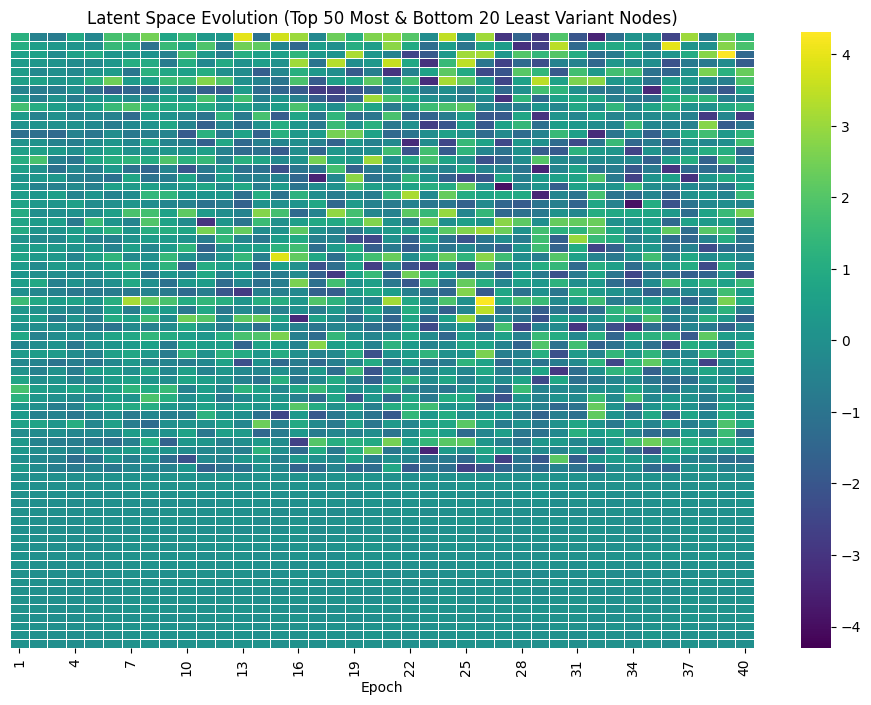

In [13]:

# Filter dataset to include only the selected nodes
df_subset = latent_variables[latent_variables['node'].isin(nodes)]

# Ensure the node ordering is preserved in the heatmap
df_subset['node'] = pd.Categorical(df_subset['node'], categories=nodes, ordered=True)

# Pivot dataframe for heatmap
heatmap_data = df_subset.pivot(index='node', columns='epoch', values='mu_first_dim')

# Plot Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='viridis', linewidths=0.5, cbar=True)

plt.xlabel("Epoch")
plt.ylabel("")  # Remove y-axis label
plt.title("Latent Space Evolution (Top 50 Most & Bottom 20 Least Variant Nodes)")
plt.xlim(0, 40)
plt.yticks([])  # Hide node labels
plt.show()


In [14]:
top_500_nodes = mu_std_per_node.sort_values(by='mu_first_dim', ascending=False).head(500)['node'].to_list()
bottom_500_nodes = mu_std_per_node.sort_values(by='mu_first_dim', ascending=True).head(500)['node'].to_list()
nodes_1k = top_nodes + bottom_nodes  # Maintain ordering: most variant → least variant

In [15]:
filename = "selected_nodes.txt"

# Write the nodes to a text file, one per line
with open(filename, "w") as f:
    for node in nodes_1k:
        f.write(str(nodes_1k) + "\n")

print(f"File saved as {filename}")

File saved as selected_nodes.txt


In [4]:
import sys
print(sys.version)


3.12.3 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:42:21) [MSC v.1916 64 bit (AMD64)]
